Created 7/2/2026

Purpose: To test out Claude generated methods for SpinSpotter improvement.

End of session notes 7/2/26
- The claude outputs are looking really good on the two examples I uploaded.
- I should definitely upload more examples!! Need to make sure we're not over-fitting the methodology to this example.
- However, it's running really slowly and checking a lot of nearby similar periods. I should prompt it to remove periods that are too close to each other and then re-implement a step at the end where the parabola comb can shift side to side to do the final step of period refinement.

Eventually:
- Bring back sector-by-sector analysis for TESS
- Ask it to explain its procedure in plain text and then go through it step by step to familiarize myself with all the individual steps and statistics.

In [1]:
# Imports
import warnings
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import spinspotter as ss
import lightkurve as lk
import pandas as pd

from scipy import stats
from astropy import units as u
from astropy.timeseries import TimeSeries, aggregate_downsample
from astropy.time import Time
from statsmodels.tsa.stattools import acf


/Users/rjholco1/miniforge3/envs/ss_sandbox/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


# Setup

In [2]:
# Helper Functions (put finished helper functions here)
def to_even_cadence(time, flux, flux_err=None, timestep=1800):
    """
    Maps a light curve onto an evenly-spaced time grid at the given cadence.
    Each original point is placed at its nearest grid index (no averaging);
    timesteps with no matching data point are filled with NaN.

    Args:
        time (array): time stamps, in days.
        flux (array): flux values.
        flux_err (array): flux_err values, if available.
        timestep (float): cadence of the output grid, in seconds (default 1800 s).

    Returns:
        time_even (array): evenly-spaced time stamps, in days.
        flux_even (array): flux values on the even grid, with NaN for gaps.
        flux_err (array): flux_err values on the even grid, if provided.
    """
    time = np.asarray(time, dtype=float)
    flux = np.asarray(flux, dtype=float)
    dt = timestep / 86400.0  # seconds -> days    
    
    # sanity check: does the requested timestep match the data's actual cadence?
    diffs = np.round(np.diff(time) * 86400).astype(int)
    values, counts = np.unique(diffs, return_counts=True)
    mode_timestep = values[np.argmax(counts)]
    if not np.isclose(timestep, mode_timestep, rtol=0.01):
        warnings.warn(
            f"Requested timestep ({timestep} s) does not match the mode "
            f"cadence of the input time array ({mode_timestep} s). "
            "The wrong timestep may have been provided."
        )

    n_bins = int(round((time[-1] - time[0]) / dt)) + 1
    time_even = time[0] + np.arange(n_bins) * dt

    idx = np.round((time - time[0]) / dt).astype(int)
    valid = (idx >= 0) & (idx < n_bins)

    flux_even = np.full(n_bins, np.nan)
    flux_even[idx[valid]] = flux[valid]
    
    if flux_err is not None:
        flux_err_even = np.full(n_bins, np.nan)
        flux_err_even[idx[valid]] = flux_err[valid]
        return time_even, flux_even, flux_err_even
        
    return time_even, flux_even

def bin_lc(time, flux, flux_err=None, binsize=1800):
    """
    Bins a timeseries to the desired cadence. Works much faster than Lightkurve's built in binning function.

    Args:
        time (:obj:`array`): time stamps of the lightcurve.
        flux (:obj:`array`): flux values of the lightcurve.
        flux_err (:obj:`array`): flux error values of the lightcurve.
        binsize (:obj:`float`): the size of the bins, in units of seconds.

    Returns:
    Two parameters, or three if a flux_err is also provided.

        - time_bin (:obj:`array`): binned time stamps of the lightcurve.
        - flux_bin (:obj:`array`): binned flux values of the lightcurve.
        - flux_err_bin (:obj:`array`): binned flux errors values of the lightcurve. Only returned if an array is passed to flux_err.
    """
    time_bin = np.arange(time[0], time[-1], binsize / 86400.0) # seconds -> days 
    flux_bin = stats.binned_statistic(time, flux, bins=time_bin)[0]

    # If flux_err is populated, assume the errors combine as the root-mean-square
    if flux_err is not None:
        # define a function to calculate the root mean square error of each bin
        rmse_func = (lambda x: np.sqrt(np.nansum(np.square(x))) / len(np.atleast_1d(x))
                    if np.any(np.isfinite(x))
                    else np.nan)
        flux_err_bin = stats.binned_statistic(time, flux_err, statistic=rmse_func, bins=time_bin)[0]
        return time_bin[:-1], flux_bin, flux_err_bin

    return time_bin[:-1], flux_bin



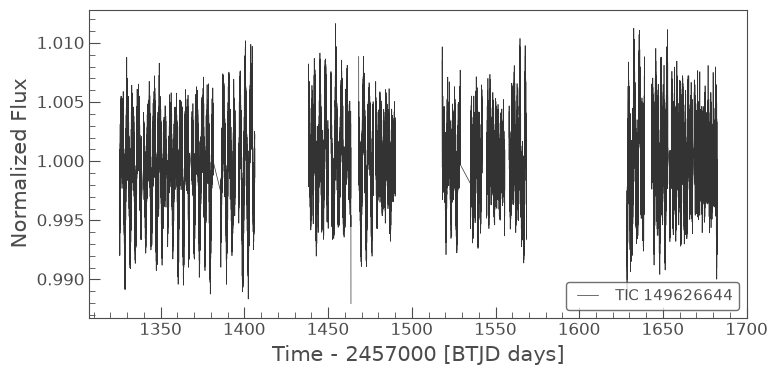

In [3]:
# open a TESS LC as a test case
# TIC 149626644, TESS Sectors 1-8
search_result = lk.search_lightcurve('TIC 149626644', mission='TESS', cadence='short', author='SPOC')
# print(search_result)

# Download
collection = search_result.download_all()

# extract
lc1 = collection.stitch().normalize()
time1 = lc1.time.mjd - lc1.time.mjd[0]
flux1 = lc1.flux.value - 1
flux_err1 = lc1.flux_err.value

# Plot, to make sure it looks correct
lc1.plot()
plt.show()



0.9983000159263611
Filename: data/tess/smarts-tess-v1.0-005025.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   ()      
  1  LIGHTCURVE    1 BinTableHDU     15   17520R x 2C   [E, E]   
  2  WAVELET       1 ImageHDU        10   (64, 64)   uint8   


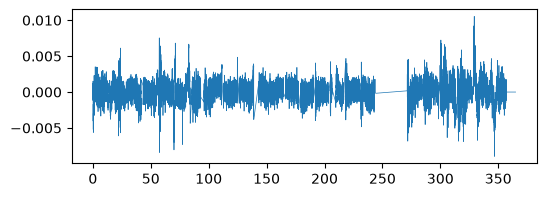

In [4]:
# open a SMARTS light curve to use as a test case
fits_path = "data/tess/smarts-tess-v1.0-005025.fits"
hdul = fits.open(fits_path)
print(hdul[0].header['PERIOD'])
hdul.info()

# extract the light curve data from the FITS file
lc2 = hdul["LIGHTCURVE"].data
time2 = lc2["time"]
flux2 = lc2["flux"] - 1
flux_err2 = ...   # some light curves may have errors, others may not
expected_period = hdul[0].header['PERIOD']
cadence = hdul[0].header['XPOSURE']

# turn into an astropy timeseries object
# ts = TimeSeries(time=Time(time, format='mjd', scale='utc'),
#                 data={'flux': flux * u.dimensionless_unscaled,
#                       'flux_err': [np.nan]*len(flux) * u.dimensionless_unscaled},
#                 names=('flux', 'flux_err'))
# ts = TimeSeries(time=Time(time, format='mjd', scale='utc'),
#                 data={'flux': flux * u.dimensionless_unscaled,},
#                 names=(('flux',)))

# plt.figure(figsize=[6,2])
# plt.plot(ts['time'].mjd, ts['flux'], lw=0.5);
plt.figure(figsize=[6,2])
plt.plot(time2, flux2, lw=0.5)
plt.show();

In [5]:
# evenize
te1, fe1 = to_even_cadence(time1, flux1, timestep=120)
te2, fe2 = to_even_cadence(time2, flux2, timestep=1800)

# they are already normalized - 1, so make the ACF
# TESS
nlags1 = ss.days_to_bins(np.floor(te1[-1] - te1[0]), 120)
acf_corr1 = acf(fe1, missing='conservative', nlags=nlags1, fft=True)
lag_times1 = ss.bins_to_days(np.arange(len(acf_corr1)), 120)
# SMARTS
nlags2 = ss.days_to_bins(np.floor(te2[-1] - te2[0]), 1800)
acf_corr2 = acf(fe2, missing='conservative', nlags=nlags2, fft=True)
lag_times2 = ss.bins_to_days(np.arange(len(acf_corr2)), 1800)


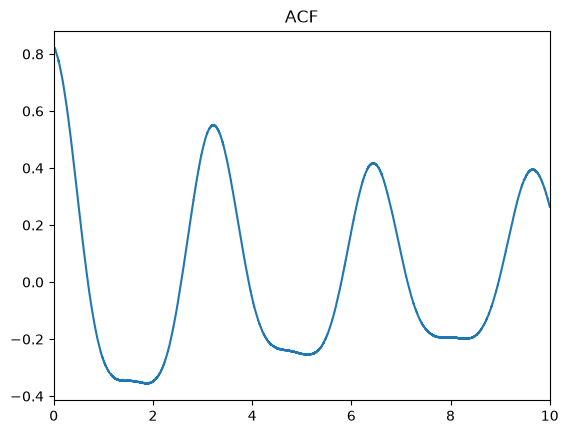

In [6]:
# TESS
plt.plot(lag_times1[10:], acf_corr1[10:])
plt.xlim([0,10])
# plt.ylim([-.2,.3])
plt.title('ACF')
plt.show()



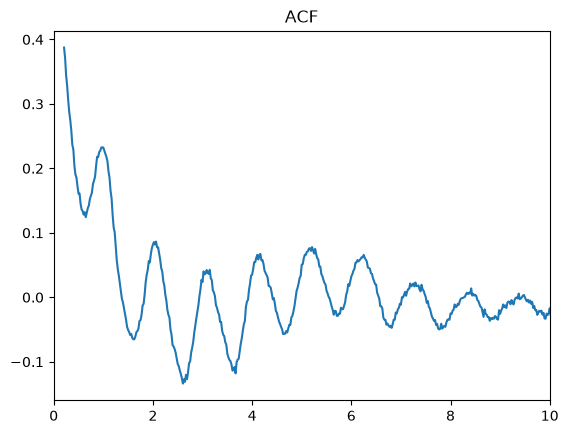

In [7]:
# SMARTS
plt.plot(lag_times2[10:], acf_corr2[10:])
plt.xlim([0,10])
# plt.ylim([-.2,.3])
plt.title('ACF')
plt.show()


# Claude testing

In [25]:
header


SIMPLE  =                    T / conforms to FITS standard
BITPIX  =                    8 / array data type
NAXIS   =                    0 / number of array dimensions
EXTEND  =                    T / 
DATE-BEG= '2018-07-25T19:29:42.708Z' / ISO-8601 formatted DateTime for obs start
DATE-END= '2019-07-17T20:29:29.973Z' / ISO-8601 formatted DateTime for obs end
DATE-AVG= '2019-01-20T07:59:36.3405Z' / ISO-8601 formatted DateTime for obs mid
DOI     = '10.17909/davg-m919' / Digital Object Identifier for HLSP data
HLSPID  = 'SMARTS'             / identifier for this HLSP collection
HLSPLEAD= 'Zachary R. Claytor' / HLSP project lead
HLSPNAME= 'Stellar Magnetism, Activity, and Rotation with Time Series' / title
HLSPTARG= 'SMARTS-TESS-v1.0-060834' / target designation
HLSPVER =                  1.0 / version identifier
INSTRUME= 'TESS'               / instrument designation
LICENSE = 'CC BY 4.0'          / license for use of these data
LICENURL= 'https://creativecommons.org/licenses/by/4.0/' 

In [8]:
# get a sense of the period distribution of the SMARTS light curves
import fitsio

file_nums = np.arange(0, 100000, 100)
fns = [f"data/tess/smarts-tess-v1.0-{num:06d}.fits" for num in file_nums]
periods = [fitsio.read_header(fn)['PERIOD'] for fn in fns]
incls = [fitsio.read_header(fn)['INCL'] for fn in fns]
diffrot = [fitsio.read_header(fn)['DIFFROT'] for fn in fns]
tspot = [fitsio.read_header(fn)['TSPOT'] for fn in fns]
activity = [fitsio.read_header(fn)['ACTIVITY'] for fn in fns]
bfly = [fitsio.read_header(fn)['BFLY'] for fn in fns]

# make into dataframe
df = pd.DataFrame(data={'filename': fns, 'periods': periods,'incls': incls,  'diffrot': diffrot, 'tspot': tspot, 'activity': activity, 'bfly': bfly})

# downselect to stuff that is likely to be more detectable
df1 = df[df.tspot > 3]

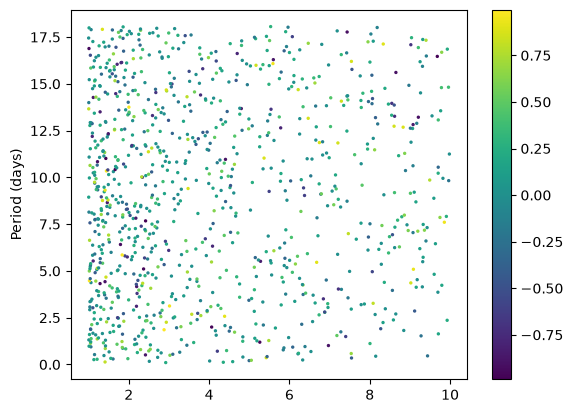

In [9]:
plt.scatter(tspot, periods, marker='o', s=2, c=diffrot)
# plt.xlabel('Inclination (rads)')
plt.ylabel('Period (days)')
plt.colorbar()
plt.show();


In [10]:
from importlib import reload
import split_smarts_lc
reload(split_smarts_lc)

<module 'split_smarts_lc' from '/Users/rjholco1/Github/ss_redevelopment/split_smarts_lc.py'>

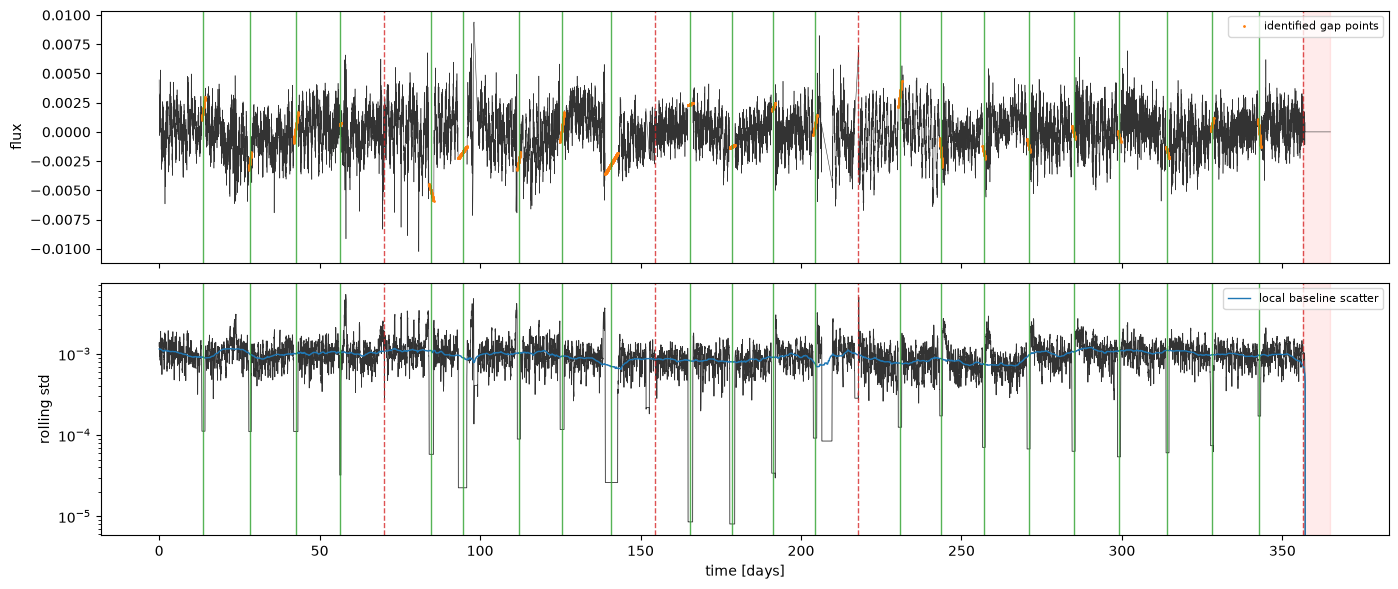

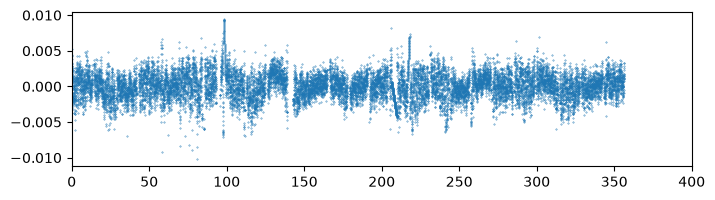

In [18]:
from split_smarts_lc import *

def unpack_smarts(fname, sectors=None):
    """
    Unpacks a SMARTS light curve FITS file and returns the time, flux, and expected period. Applies normalization and maps it to even cadence for conveniences

    Args:
        filename (str): Path to the SMARTS light curve FITS file.
    Returns:
        time (array): time stamps, in days. 
        flux (array): flux values, normalized to 1 and centered around 0.
        time_even (array): time stamps, mapped to even cadence.
        flux_even (array): flux, mapped to even cadence.        
        header (float): the header of the FITS file, which contains metadata including the expected rotation period.
    """
    hdul = fits.open(fname)
    lc = hdul["LIGHTCURVE"].data
    time = lc["time"]
    flux = lc["flux"] - 1
    
    # split the light curve and then recombine it to remove gaps and flagged segments, 
    segments, diagnostics = split_lightcurve(time, flux, n_segments=27)
    time_stitch, flux_stitch, sectors = recombine_segments(
        segments, diagnostics, 
        drop_gap_points=True, drop_flagged_segments=True,
        sectors=sectors)
    
    # then map to even cadence
    time_even, flux_even = to_even_cadence(time_stitch, flux_stitch, timestep=1800)
    header = hdul[0].header
    return time, flux, segments, diagnostics, time_stitch, flux_stitch, time_even, flux_even, header, sectors

# fname = df1.filename.iloc[118]
# fname = df1.filename.iloc[296]
fname = df1.filename.iloc[27]
time_raw, flux_raw, segments, diagnostics, time_stitch, flux_stitch, time_even, flux_even, header, sectors = unpack_smarts(fname)

# we want to treat the stitched version as default
time, flux = time_stitch, flux_stitch

# segments, diagnostics = split_lightcurve(time, flux, n_segments=27)
plot_split_diagnostics(time_raw, flux_raw, diagnostics)
plt.show();

plt.figure(figsize=[8,2])
plt.scatter(time_stitch, flux_stitch, s=.1)
plt.xlim([0, 400])
plt.show()


LightCurveCollection of 5 objects:
    0: <LightCurve SECTOR=1>
    1: <LightCurve SECTOR=2>
    2: <LightCurve SECTOR=6>
    3: <LightCurve SECTOR=7>
    4: <LightCurve SECTOR=12>


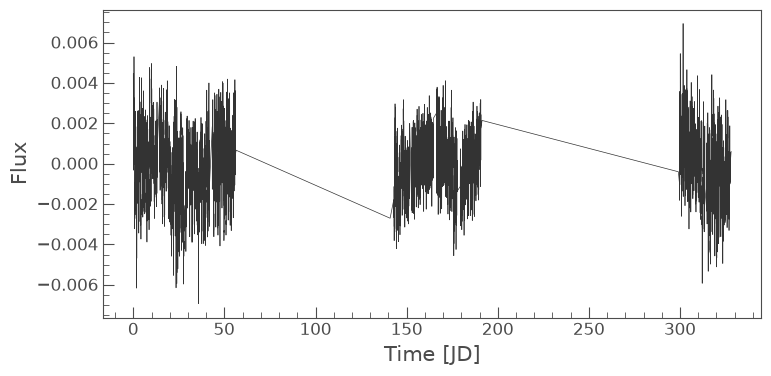

In [ ]:
# example usage of segments_to_lightkurve()
lcc, sectors = segments_to_lightkurve(segments, diagnostics=diagnostics, exclude_flagged=True, sectors=[1, 2, 6, 7, 12])
print(lcc)
lcc.stitch(corrector_func=None).plot()
# lcc[2].plot()
plt.show();

In [ ]:
# np.savez('smarts_lc_bad2.npz', time=time, flux=flux)

11.00069999694824
Filename: data/tess/smarts-tess-v1.0-060834.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   ()      
  1  LIGHTCURVE    1 BinTableHDU     15   17520R x 2C   [E, E]   
  2  WAVELET       1 ImageHDU        10   (64, 64)   uint8   
Expected period from SMARTS header: 11.00069999694824


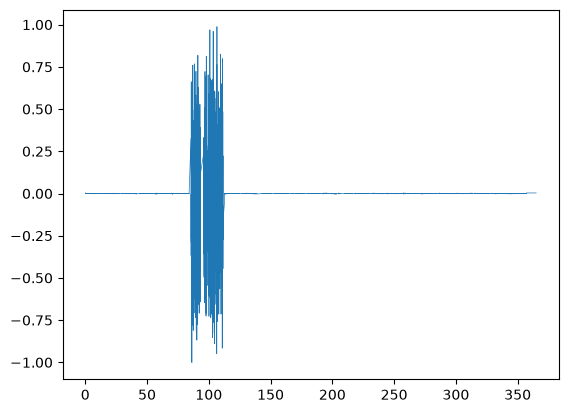

In [13]:
# open a SMARTS light curve to use as a test case
# fits_path = "data/tess/smarts-tess-v1.0-005025.fits"
# fits_path = "data/tess/smarts-tess-v1.0-060842.fits"
# fits_path = "data/tess/smarts-tess-v1.0-060844.fits"
# fits_path = "data/tess/smarts-tess-v1.0-060834.fits" # BAD LC!!!
hdul = fits.open(fits_path)
print(hdul[0].header['PERIOD'])
hdul.info()

# extract the light curve data from the FITS file
lc2 = hdul["LIGHTCURVE"].data
time2 = lc2["time"]
flux2 = lc2["flux"] - 1
# time2 = time2[len(time2)//2:]
# flux2 = flux2[len(flux2)//2:]

flux_err2 = ...   # some light curves may have errors, others may not
expected_period = hdul[0].header['PERIOD']
cadence = hdul[0].header['XPOSURE']

print('Expected period from SMARTS header:', expected_period)

# evenize
te2, fe2 = to_even_cadence(time2, flux2, timestep=1800)

plt.plot(te2, fe2, lw=0.5)
plt.show()

# # SMARTS
# nlags2 = ss.days_to_bins(np.floor(te2[-1] - te2[0]), 1800)
# acf_corr2 = acf(fe2, missing='conservative', nlags=nlags2, fft=True)
# lag_times2 = ss.bins_to_days(np.arange(len(acf_corr2)), 1800)

Gathered 15 candidate periods (failed methods: none)

Selected P=8.986 from 1 candidate(s) that passed reliability gates (of 13 tested).
Fitted period: 8.9863 d  (true=13.7)
Peaks used: 5  dropped: 0  reduced chi^2: 0.0001792

Acceptance diagnostics for the winner:
  n_peaks_used: 5
  n_peaks_dropped: 0
  redchi: 0.0001792169851034376
  heights: [1.19882416 0.01127358 0.04392379 0.16969811 0.21545758]
  height_snr: [8.02012229 0.07542014 0.29384972 1.13527878 1.44140918]
  curvatures: [0.0098487  0.00072894 0.00031856 0.00056331 0.00034337]
  frac_non_increasing_height: 0.25
  frac_positive_heights: 1.0
  passes_min_peaks: True
  passes_redchi: True
  passes_height_snr: False


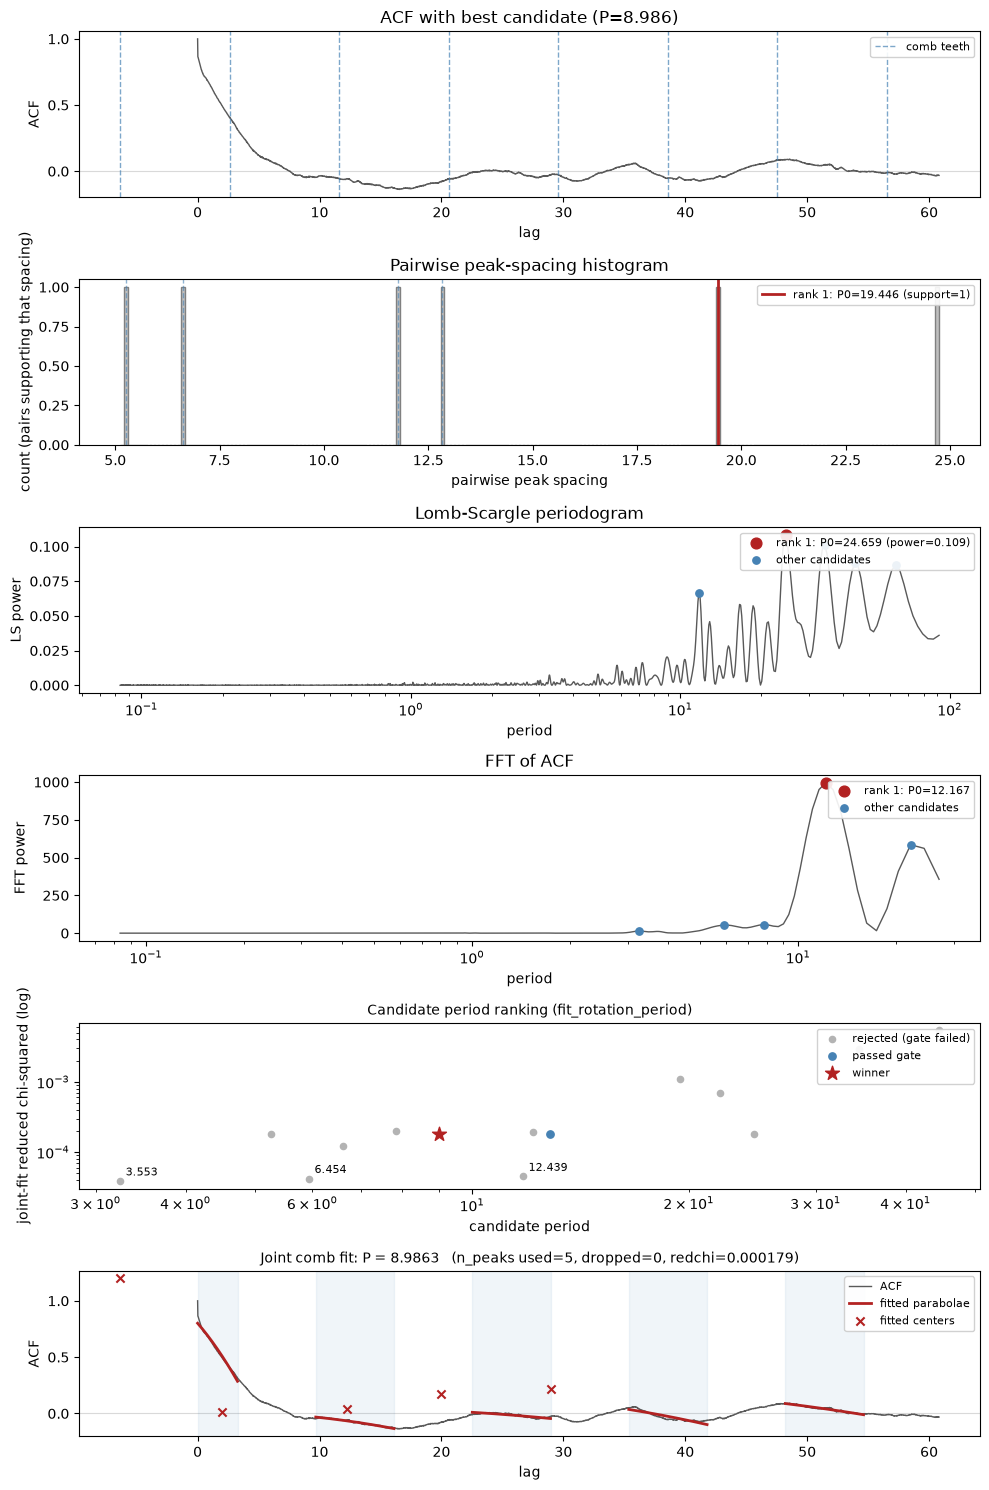

In [32]:
"""
example_usage.py

Minimal end-to-end demo of comb_fit.py (v2) on a synthetic quasi-periodic
light curve: build the ACF, gather candidate periods from all three
guess_* methods, fit and arbitrate between them with fit_rotation_period,
and inspect/plot the result.
"""
import sys
sys.path.insert(0, "claude_files")

import numpy as np
from comb_fit import gather_initial_guesses, fit_rotation_period, assess_rotation_candidate
from plotting import plot_full_diagnostic


def compute_acf(time, flux, max_lag_frac=1 / 3):
    """Simple FFT-based autocorrelation of an evenly-sampled light curve
    (no gaps). For real data with NaN-filled gaps, use acf_utils.compute_acf
    instead -- see example_messy_data.py.
    """
    x = flux - np.mean(flux)
    n = len(x)
    f = np.fft.fft(x, n=2 * n)
    acf_full = np.fft.ifft(f * np.conj(f)).real[:n]
    acf_full /= acf_full[0]
    dt = np.median(np.diff(time))
    lags = np.arange(n) * dt
    mask = lags <= lags[-1] * max_lag_frac
    return lags[mask], acf_full[mask]


if __name__ == "__main__":
    # # --- synthetic light curve: two spot harmonics + slow amplitude decay + noise ---
    # rng = np.random.default_rng(0)
    # true_P = 13.7  # days
    # time = np.arange(0, 80.0, 0.02)
    # phase = 2 * np.pi * time / true_P
    # amp_mod = 1.0 + 0.4 * np.sin(2 * np.pi * time / (true_P * 9))
    # flux = 1.0 + 0.01 * amp_mod * (np.sin(phase) + 0.4 * np.sin(2 * phase + 0.3))
    # flux += rng.normal(0, 0.0015, size=time.size)
    # flux /= np.median(flux)

    time = te2
    flux = fe2
    acf_lags, acf = compute_acf(time, flux)

    # --- 1. gather candidate periods from all three methods ---
    # Each guess_* function proposes its own top n_guesses candidates,
    # ranked by its own method-specific evidence, WITHOUT checking them
    # against the ACF's shape -- that happens next, in fit_rotation_period.
    guesses, failed_methods = gather_initial_guesses(time, flux, acf_lags, acf, n_guesses=5)
    print(f"Gathered {len(guesses)} candidate periods "
          f"(failed methods: {failed_methods or 'none'})")

    # --- 2. fit every candidate and let the joint comb fit arbitrate ---
    result = fit_rotation_period(acf_lags, acf, guesses)

    print(f"\n{result.message}")
    if not result.success:
        print("No reliable rotation period found for this light curve.")
    else:
        print(f"Fitted period: {result.best_fit.P:.4f} d  (true={true_P})")
        print(f"Peaks used: {result.best_fit.n_peaks_used}  "
              f"dropped: {result.best_fit.n_peaks_dropped}  "
              f"reduced chi^2: {result.best_fit.redchi:.4g}")

        diagnostics = assess_rotation_candidate(result.best_fit, acf)
        print("\nAcceptance diagnostics for the winner:")
        for k, v in diagnostics.items():
            print(f"  {k}: {v}")

# --- 3. diagnostic plots ---
fig, axes = plot_full_diagnostic(acf_lags, acf, guesses, result)
plt.show()
# fig.savefig("comb_fit_diagnostic.png", dpi=120)
# print("\nSaved diagnostic figure to comb_fit_diagnostic.png")


# OLD

In [ ]:
# imports + helper funtions
"""
example_usage.py

Minimal end-to-end demo of comb_fit.py on a synthetic quasi-periodic light
curve: build the ACF, get an initial (P, t0) guess (swap between the three
methods freely), run the joint comb fit, and inspect the result.
"""
import sys
sys.path.insert(0, "claude_files")

import numpy as np
from comb_fit import (
    guess_pairwise_histogram,
    guess_lombscargle,
    guess_acf_fft,
    fit_rotation_period,
    assess_rotation_candidate,
)
from plotting import plot_full_diagnostic
from acf_utils import compute_acf
from comb_fit import find_best_rotation_period, assess_rotation_candidate
from plotting import plot_comb_fit, plot_candidate_ranking


# def compute_acf(time, flux, max_lag_frac=1 / 3):
#     """Simple FFT-based autocorrelation of an evenly-sampled light curve."""
#     x = flux - np.mean(flux)
#     n = len(x)
#     f = np.fft.fft(x, n=2 * n)
#     acf_full = np.fft.ifft(f * np.conj(f)).real[:n]
#     acf_full /= acf_full[0]
#     dt = np.median(np.diff(time))
#     lags = np.arange(n) * dt
#     mask = lags <= lags[-1] * max_lag_frac
#     return lags[mask], acf_full[mask]




ImportError: cannot import name 'find_best_rotation_period' from 'comb_fit' (/Users/rjholco1/Github/ss_sandbox/claude_files/comb_fit.py)

## Development of smarts lc splitting code

In [ ]:
from importlib import reload
import split_smarts_lc
reload(split_smarts_lc)

<module 'split_smarts_lc' from '/Users/rjholco1/Github/ss_sandbox/split_smarts_lc.py'>

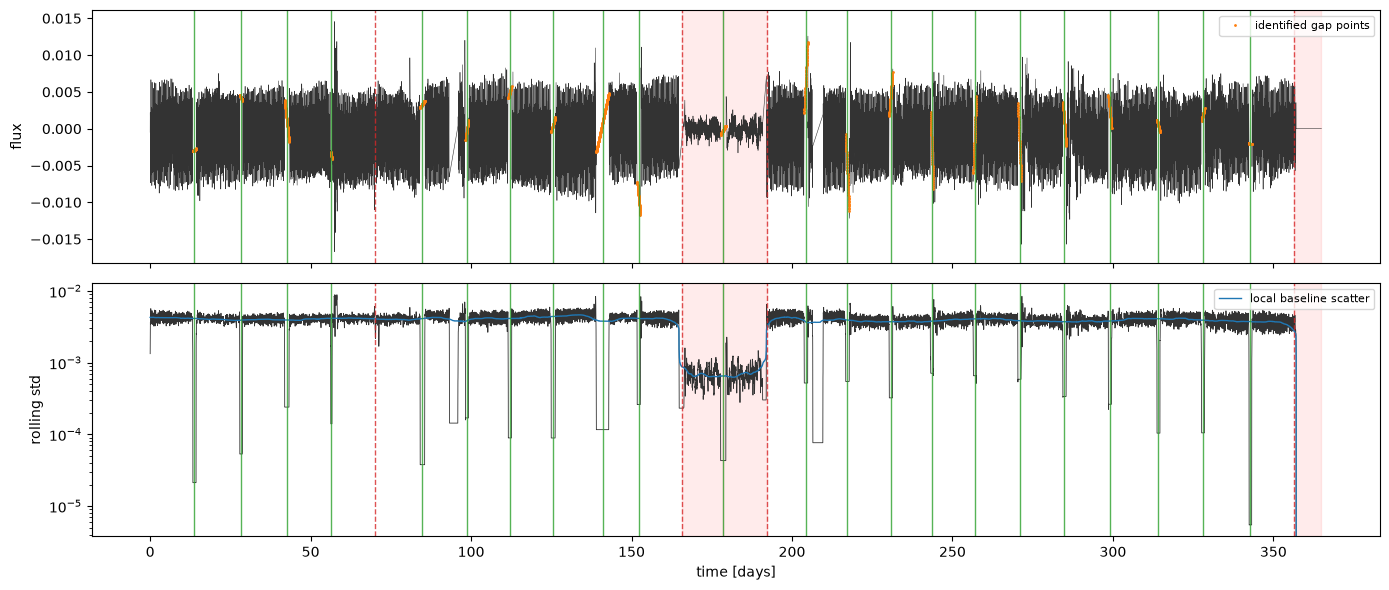

In [ ]:
from split_smarts_lc import find_candidate_gaps, split_lightcurve, plot_split_diagnostics, segments_to_lightkurve, recombine_segments

# segments, diagnostics = split_lightcurve(time, flux, n_sectors=13, mode='orbits')
segments, diagnostics = split_lightcurve(time, flux, n_sectors=27, mode='sector',
                                         remove_gap_points=False)

plot_split_diagnostics(time, flux, diagnostics)
plt.show();

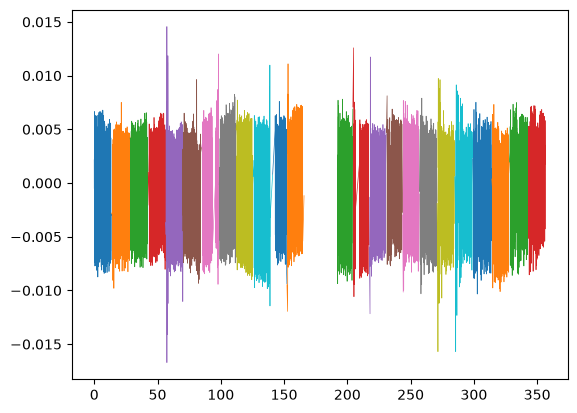

In [ ]:
diagnostics.keys()
# segments[diagnostics['segment_flagged']]
# diagnostics['segment_flagged']

np.array(segments[0])

# [plt.plot(segments[i][0] - min(segments[i][0]), segments[i][1], lw=0.5) for i in range(len(segments))]
[plt.plot(segments[i][0], segments[i][1], lw=0.5) for i in range(len(segments)) if not diagnostics['segment_flagged'][i]]
# plt.xlim([25,30])
plt.show()

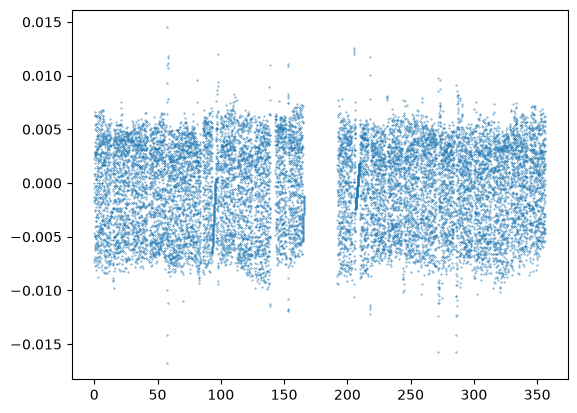

In [ ]:
time_stitch, flux_stitch = recombine_segments(segments, diagnostics, drop_gap_points=True,
                        drop_flagged_segments=True)
plt.scatter(time_stitch, flux_stitch, s=.1)
plt.show()


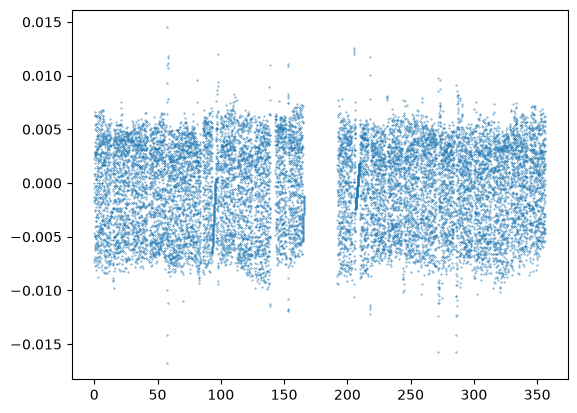

In [ ]:
time_stitch = np.concat([segments[i][0]for i in range(len(segments)) if not diagnostics['segment_flagged'][i]])
flux_stitch = np.concat([segments[i][1]for i in range(len(segments)) if not diagnostics['segment_flagged'][i]])
plt.scatter(time_stitch, flux_stitch, s=.1)
plt.show()

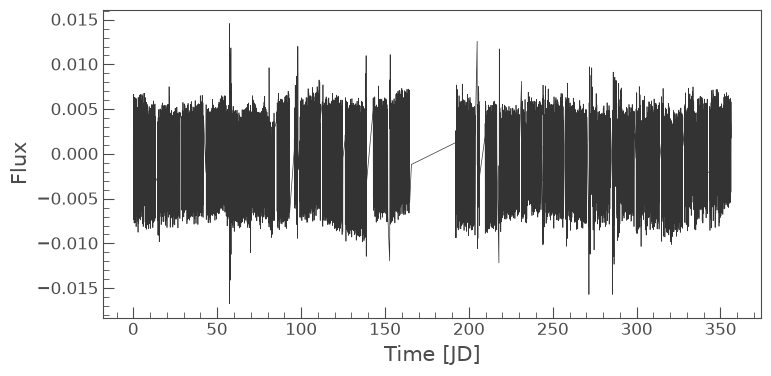

In [ ]:
lcc = segments_to_lightkurve(segments, mode='orbit', exclude_flagged=True, diagnostics=diagnostics)
# plt.plot(lcc[6].time.value, lcc[6].flux.value)
# plt.show()

lcc.stitch(corrector_func=None).plot();
plt.show()

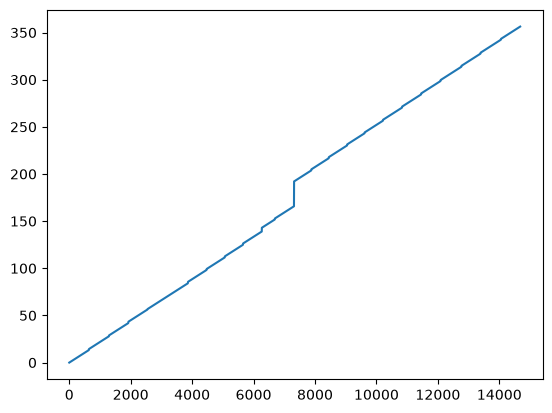

In [ ]:
plt.plot(lcc.stitch(corrector_func=None).time.value)
plt.show()

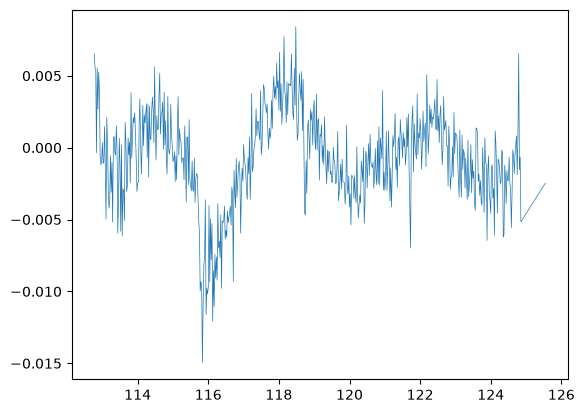

In [ ]:
len(segments[8][0]), len(segments[8][1])
plt.plot(segments[8][0], segments[8][1], lw=0.5)
plt.show()

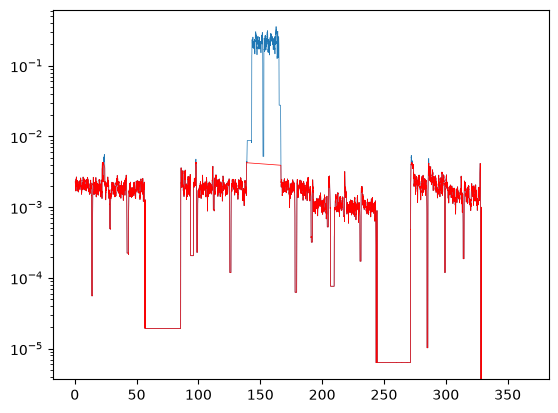

In [ ]:
fname = df1.filename.iloc[321]
# hdul = fits.open(fname)
# hdul[1].header
time, flux, time_even, flux_even, expected_period = unpack_smarts(fname)

# try rolling stddev
lcd = pd.DataFrame({'time': time, 'flux': flux})

# 2. Calculate rolling standard deviation with a window size of 3
lcd['rolling_std'] = lcd['flux'].rolling(window=20).std()

from astropy.stats import sigma_clip
# 3. Apply sigma clipping to the rolling standard deviation
clipped = sigma_clip((lcd['rolling_std']), sigma_lower=2.5, sigma_upper=3, maxiters=5)

plt.plot(lcd['time'], lcd['rolling_std'], lw=0.5)
plt.plot(lcd['time'][~clipped.mask], lcd['rolling_std'][~clipped.mask], lw=0.5, color='red')
plt.yscale('log')
# plt.xlim([20, 30])
plt.show()

In [ ]:
cycles

array([ 0.,  0.,  0., ..., 21., 21., 21.], shape=(17520,), dtype=float32)

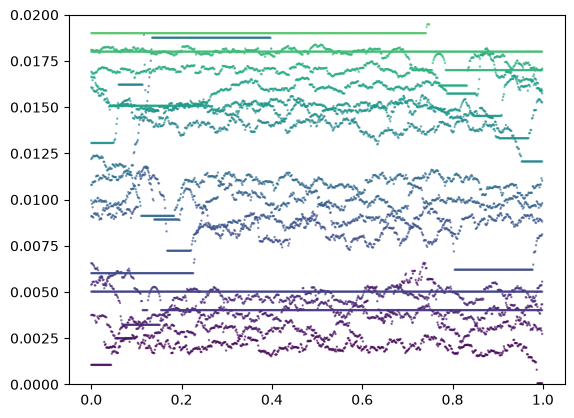

In [ ]:
# try phase folding cuts
true_period = 27.5 / 2
t0 = 0

# Signal dips every 4.2 days
flux1 = flux.copy()
flux1 += np.random.normal(0, 0.01, size=len(time)) # Add noise

# 2. Perform Phase Folding
# Calculate phase normalized between 0 and 1
phases = ((time - t0) % true_period) / true_period
cycles = (time - t0) // true_period

# Alternatively, normalize phase between -0.5 and 0.5
phases_centered = ((time - t0 + 0.5 * true_period) % true_period) / true_period - 0.5

# 3. Plot the results
# plt.scatter(phases, flux1+cycles, s=.5, c=cycles, alpha=0.6)
plt.scatter(phases, lcd['rolling_std']+cycles/1000, s=.5, c=cycles, alpha=0.6)
plt.ylim([0, 0.02])
plt.show()

In [ ]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# ax1.scatter(time, flux1, s=5, color='black')
# ax1.set_title("Raw Time-Series Data")
# ax1.set_xlabel("Time (days)")
# ax1.set_ylabel("Flux1")

# ax2.scatter(phases, flux1, s=5, c=cycles, alpha=0.6)
# ax2.set_title(f"Phase Folded Data (P = {true_period})")
# ax2.set_xlabel("Phase (0 to 1)")
# ax2.set_ylabel("Flux1")

# plt.tight_layout()
# plt.show()

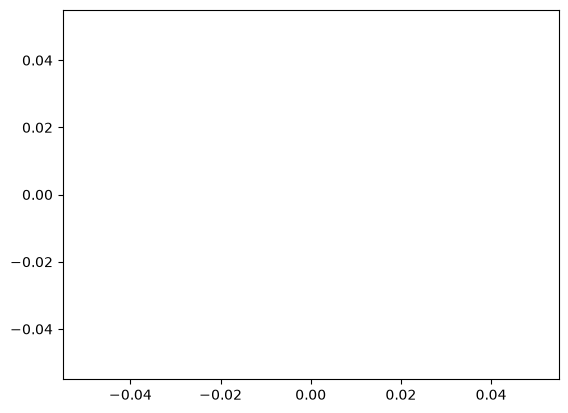

In [ ]:
filter = (cycles == 21)
plt.scatter(phases[filter], flux1[filter]+cycles[filter], s=.5, c=cycles[filter], alpha=0.6)
plt.show()

## Old usage of the find_best_rotation_period function, which is now deprecated in favor of the new fit_rotation_period function.

Initial guess (pairwise_histogram): P0=3.7270  t0=3.6379
Fitted period: 3.7040 d  (true=3.7)
Peaks used: 7  dropped: 0  reduced chi^2: 0.0003169

Acceptance diagnostics:
  n_peaks_used: 7
  n_peaks_dropped: 0
  redchi: 0.0003169232931367327
  heights: [0.91453853 0.85011465 0.78204315 0.74026761 0.74944494 0.80890615
 0.89693275]
  height_snr: [1.73159789 1.60961698 1.48072959 1.4016313  1.41900778 1.53159232
 1.69826291]
  curvatures: [1.47657484 1.37849466 1.27712898 1.20025067 1.21973095 1.31274334
 1.48193988]
  frac_non_increasing_height: 0.5
  passes_min_peaks: True
  passes_redchi: True
  passes_height_snr: False


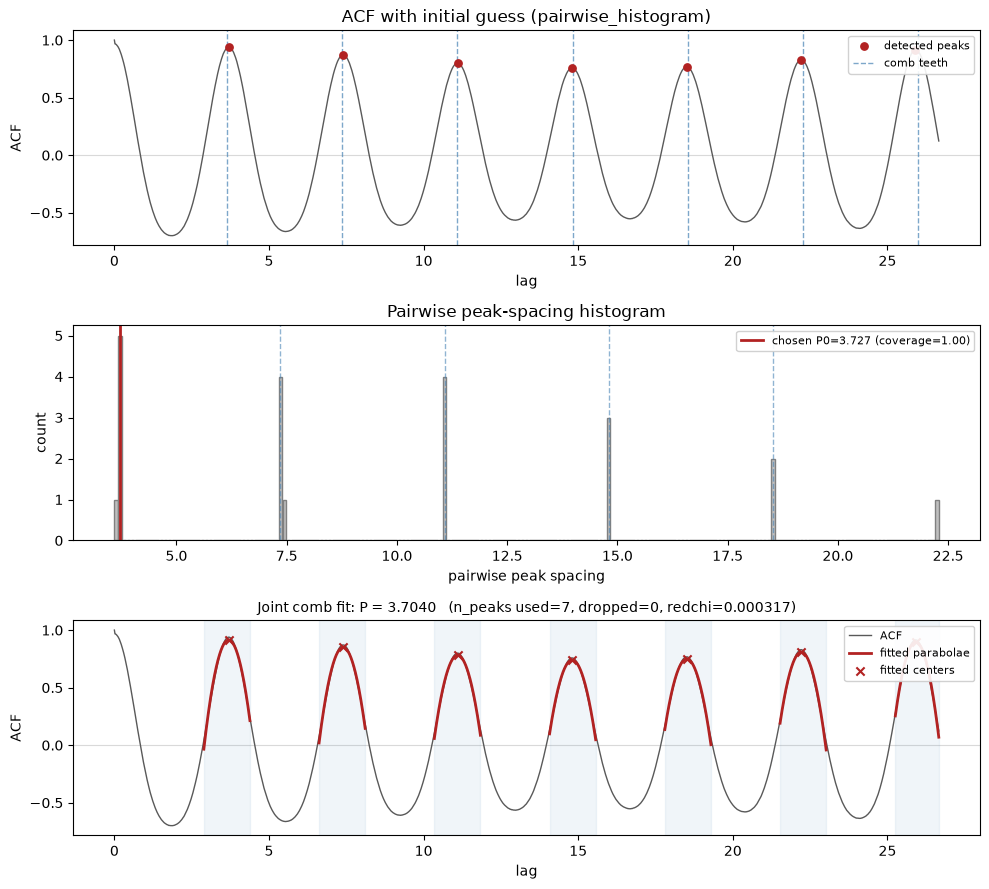


Saved diagnostic figure to comb_fit_diagnostic.png


In [ ]:
if __name__ == "__main__":
    # --- synthetic light curve: two spot harmonics + slow amplitude decay + noise ---
    rng = np.random.default_rng(0)
    true_P = 3.7  # days
    time = np.arange(0, 80.0, 0.02)
    phase = 2 * np.pi * time / true_P
    amp_mod = 1.0 + 0.4 * np.sin(2 * np.pi * time / (true_P * 9))
    flux = 1.0 + 0.01 * amp_mod * (np.sin(phase) + 0.4 * np.sin(2 * phase + 0.3))
    flux += rng.normal(0, 0.0015, size=time.size)
    flux /= np.median(flux)

    acf_lags, acf = compute_acf(time, flux)

    # --- pick ONE initial-guess method (all three share the same call signature) ---
    guess = guess_pairwise_histogram(time, flux, acf_lags, acf, prominence=0.01)
    # guess = guess_lombscargle(time, flux, acf_lags, acf)
    # guess = guess_acf_fft(time, flux, acf_lags, acf)

    print(f"Initial guess ({guess.method}): P0={guess.P0:.4f}  t0={guess.t0:.4f}")

    # --- joint comb fit ---
    fit = fit_rotation_period(acf_lags, acf, guess, n_peaks=8, window_frac=0.2)
    print(f"Fitted period: {fit.P:.4f} d  (true={true_P})")
    print(f"Peaks used: {fit.n_peaks_used}  dropped: {fit.n_peaks_dropped}  "
          f"reduced chi^2: {fit.redchi:.4g}")

    # --- goodness-of-fit / acceptance diagnostics ---
    diagnostics = assess_rotation_candidate(fit, acf)
    print("\nAcceptance diagnostics:")
    for k, v in diagnostics.items():
        print(f"  {k}: {v}")

    # --- diagnostic plots ---
    fig, axes = plot_full_diagnostic(acf_lags, acf, guess, fit)
    plt.show();
    # fig.savefig("comb_fit_diagnostic.png", dpi=120)
    print("\nSaved diagnostic figure to comb_fit_diagnostic.png")


Initial guess (pairwise_histogram): P0=3.7270  t0=3.6379
Fitted period: 3.7040 d  (true=3.7)
Peaks used: 7  dropped: 0  reduced chi^2: 0.0003169

Acceptance diagnostics:
  n_peaks_used: 7
  n_peaks_dropped: 0
  redchi: 0.0003169232931367327
  heights: [0.91453853 0.85011465 0.78204315 0.74026761 0.74944494 0.80890615
 0.89693275]
  height_snr: [1.73159789 1.60961698 1.48072959 1.4016313  1.41900778 1.53159232
 1.69826291]
  curvatures: [1.47657484 1.37849466 1.27712898 1.20025067 1.21973095 1.31274334
 1.48193988]
  frac_non_increasing_height: 0.5
  passes_min_peaks: True
  passes_redchi: True
  passes_height_snr: False


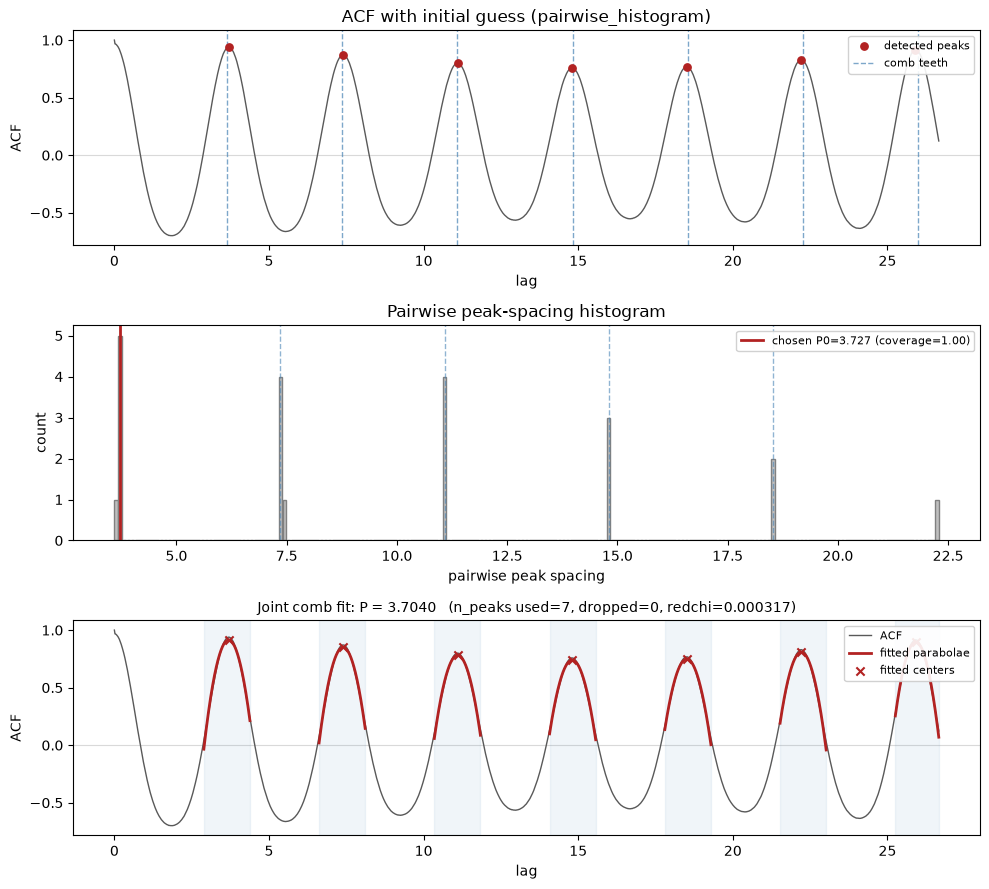


Saved diagnostic figure to comb_fit_diagnostic.png


In [ ]:
# with claude-generated data
if __name__ == "__main__":
    # --- synthetic light curve: two spot harmonics + slow amplitude decay + noise ---
    rng = np.random.default_rng(0)
    true_P = 3.7  # days
    time = np.arange(0, 80.0, 0.02)
    phase = 2 * np.pi * time / true_P
    amp_mod = 1.0 + 0.4 * np.sin(2 * np.pi * time / (true_P * 9))
    flux = 1.0 + 0.01 * amp_mod * (np.sin(phase) + 0.4 * np.sin(2 * phase + 0.3))
    flux += rng.normal(0, 0.0015, size=time.size)
    flux /= np.median(flux)

    acf_lags, acf = compute_acf(time, flux)

    # --- pick ONE initial-guess method (all three share the same call signature) ---
    guess = guess_pairwise_histogram(time, flux, acf_lags, acf, prominence=0.01)
    # guess = guess_lombscargle(time, flux, acf_lags, acf)
    # guess = guess_acf_fft(time, flux, acf_lags, acf)

    print(f"Initial guess ({guess.method}): P0={guess.P0:.4f}  t0={guess.t0:.4f}")

    # --- joint comb fit ---
    fit = fit_rotation_period(acf_lags, acf, guess, n_peaks=8, window_frac=0.2)
    print(f"Fitted period: {fit.P:.4f} d  (true={true_P})")
    print(f"Peaks used: {fit.n_peaks_used}  dropped: {fit.n_peaks_dropped}  "
          f"reduced chi^2: {fit.redchi:.4g}")

    # --- goodness-of-fit / acceptance diagnostics ---
    diagnostics = assess_rotation_candidate(fit, acf)
    print("\nAcceptance diagnostics:")
    for k, v in diagnostics.items():
        print(f"  {k}: {v}")

    # --- diagnostic plots ---
    fig, axes = plot_full_diagnostic(acf_lags, acf, guess, fit)
    plt.show();
    # fig.savefig("comb_fit_diagnostic.png", dpi=120)
    print("\nSaved diagnostic figure to comb_fit_diagnostic.png")

ACF computed: 34395 lag points, max lag = 47.77 d

Tested 75 candidate periods across 3 guess methods (failed: none)
Best period: P = 3.2728 d
  n_peaks_used=8  redchi=0.001242

Top 5 candidates (period, fitted P, n_peaks_used, redchi):
    3.2197 ->   3.2728  n_used=8  redchi=0.001242
    3.1039 ->   3.3221  n_used=8  redchi=0.003778
    3.3590 ->   3.1710  n_used=8  redchi=0.005564
    2.9857 ->   3.5045  n_used=8  redchi=0.008389
    6.3272 ->   6.4594  n_used=8  redchi=0.02438

Acceptance diagnostics for the winner:
  n_peaks_used: 8
  n_peaks_dropped: 0
  redchi: 0.0012416895481569554
  heights: [0.8642408  0.65643525 0.56449135 0.56981548 0.54907358 0.54538352
 0.50697552 0.53294455]
  height_snr: [2.63645728 2.00252462 1.72204011 1.73828192 1.67500658 1.66374967
 1.54658203 1.62580327]
  curvatures: [1.10627249 1.41486695 1.24599692 1.18310785 1.14295545 1.11657195
 1.0466573  1.04021049]
  frac_non_increasing_height: 0.7142857142857143
  passes_min_peaks: True
  passes_redchi: 

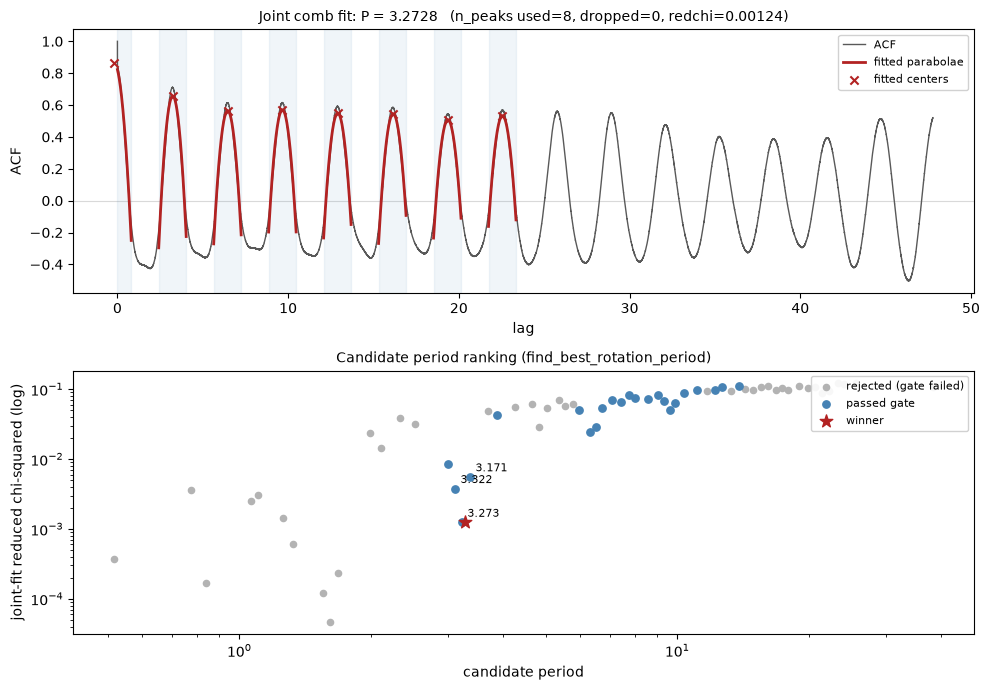


Saved diagnostic figure to messy_data_diagnostic.png


In [ ]:
# with TESS data
if __name__ == "__main__":
    # --- synthetic light curve: two spot harmonics + slow amplitude decay + noise ---
    flux, time = fe1, te1
    acf_lags, acf = lag_times1, acf_corr1
    true_P = 3.5
    
    # --- 1. gap-aware ACF ---
    acf_lags, acf = compute_acf(time, flux, max_lag_frac=1 / 3, min_valid_frac=0.3)
    print(f"ACF computed: {len(acf_lags)} lag points, max lag = {acf_lags[-1]:.2f} d")

    # --- 2. ensemble initial guess + joint-fit arbitration ---
    # If you have ANY prior expectation of the period range (spectral type,
    # literature, visual inspection of the light curve), pass min_period /
    # max_period here -- it meaningfully speeds things up and keeps
    # physically-impossible candidates out of contention. Left blank here
    # to demonstrate the fully-blind case.
    result = find_best_rotation_period(
        time, flux, acf_lags, acf,
        n_top_peaks=5,       # how many of each method's own top candidates to pool
        min_teeth=4,          # guard against few-tooth candidates winning trivially
        min_peaks_required=4, # winning candidate must retain at least this many peaks
    )

    print(f"\nTested {result.n_candidates_tried} candidate periods across "
          f"{3 - len(result.failed_methods)} guess methods "
          f"(failed: {result.failed_methods or 'none'})")
    print(f"Best period: P = {result.best_fit.P:.4f} d")
    print(f"  n_peaks_used={result.best_fit.n_peaks_used}  "
          f"redchi={result.best_fit.redchi:.4g}")

    print("\nTop 5 candidates (period, fitted P, n_peaks_used, redchi):")
    for c in result.candidates[:5]:
        print(f"  {c.period:8.4f} -> {c.fit.P:8.4f}  "
              f"n_used={c.fit.n_peaks_used}  redchi={c.fit.redchi:.4g}")

    diagnostics = assess_rotation_candidate(result.best_fit, acf)
    print("\nAcceptance diagnostics for the winner:")
    for k, v in diagnostics.items():
        print(f"  {k}: {v}")

    # --- 3. diagnostic plots ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    plot_comb_fit(acf_lags, acf, result.best_fit, ax=axes[0])
    plot_candidate_ranking(result, ax=axes[1])
    fig.tight_layout()
    # fig.savefig("messy_data_diagnostic.png", dpi=120)
    plt.show();
    # print("\nSaved diagnostic figure to messy_data_diagnostic.png")

Initial guess (acf_fft): P0=3.1875  t0=0.0520
Fitted period: 3.2134 d  (true=3.5)
Peaks used: 6  dropped: 2  reduced chi^2: 0.0001826

Acceptance diagnostics:
  n_peaks_used: 6
  n_peaks_dropped: 2
  redchi: 0.000182563584956866
  heights: [0.40124026 0.38105835 0.37569819 0.33483857 0.27067182 0.2594959 ]
  height_snr: [4.61741006 4.38515976 4.32347597 3.85326981 3.11484896 2.98623816]
  curvatures: [1.01913563 0.90498346 0.88017785 0.75835589 0.5822863  0.50042703]
  frac_non_increasing_height: 1.0
  passes_min_peaks: True
  passes_redchi: True
  passes_height_snr: False


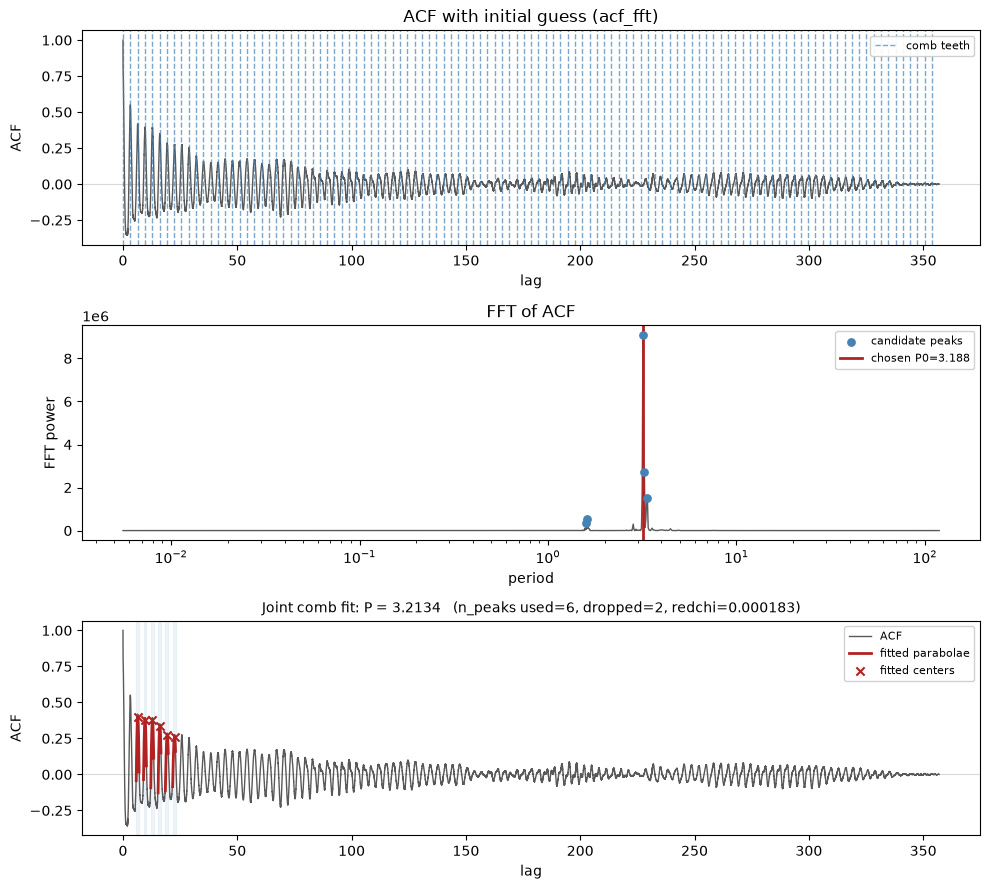


Saved diagnostic figure to comb_fit_diagnostic.png


In [ ]:
# with TESS data OLD
if __name__ == "__main__":
    # --- synthetic light curve: two spot harmonics + slow amplitude decay + noise ---
    flux, time = fe1, te1
    acf_lags, acf = lag_times1, acf_corr1
    true_P = 3.5

    # --- pick ONE initial-guess method (all three share the same call signature) ---
    # guess = guess_pairwise_histogram(time, flux, acf_lags, acf, prominence=0.01)
    # guess = guess_lombscargle(time, flux, acf_lags, acf)
    guess = guess_acf_fft(time, flux, acf_lags, acf)

    print(f"Initial guess ({guess.method}): P0={guess.P0:.4f}  t0={guess.t0:.4f}")

    # --- joint comb fit ---
    fit = fit_rotation_period(acf_lags, acf, guess, n_peaks=8, window_frac=0.2)
    print(f"Fitted period: {fit.P:.4f} d  (true={true_P})")
    print(f"Peaks used: {fit.n_peaks_used}  dropped: {fit.n_peaks_dropped}  "
          f"reduced chi^2: {fit.redchi:.4g}")

    # --- goodness-of-fit / acceptance diagnostics ---
    diagnostics = assess_rotation_candidate(fit, acf)
    print("\nAcceptance diagnostics:")
    for k, v in diagnostics.items():
        print(f"  {k}: {v}")

    # --- diagnostic plots ---
    fig, axes = plot_full_diagnostic(acf_lags, acf, guess, fit)
    plt.show();
    # fig.savefig("comb_fit_diagnostic.png", dpi=120)
    print("\nSaved diagnostic figure to comb_fit_diagnostic.png")

In [ ]:
# with SMARTS data
if __name__ == "__main__":
    flux, time = fe2, te2
    acf_lags, acf = lag_times2, acf_corr2
    true_P = expected_period
    
    # --- 1. gap-aware ACF ---
    acf_lags, acf = compute_acf(time, flux, max_lag_frac=1 / 3, min_valid_frac=0.3)
    print(f"ACF computed: {len(acf_lags)} lag points, max lag = {acf_lags[-1]:.2f} d")

    # --- 2. ensemble initial guess + joint-fit arbitration ---
    # If you have ANY prior expectation of the period range (spectral type,
    # literature, visual inspection of the light curve), pass min_period /
    # max_period here -- it meaningfully speeds things up and keeps
    # physically-impossible candidates out of contention. Left blank here
    # to demonstrate the fully-blind case.
    result = find_best_rotation_period(
        time, flux, acf_lags, acf,
        n_top_peaks=15,       # how many of each method's own top candidates to pool
        min_teeth=4,          # guard against few-tooth candidates winning trivially
        min_peaks_required=4, # winning candidate must retain at least this many peaks
    )

    print(f"\nTested {result.n_candidates_tried} candidate periods across "
          f"{3 - len(result.failed_methods)} guess methods "
          f"(failed: {result.failed_methods or 'none'})")
    print(f"Best period: P = {result.best_fit.P:.4f} d")
    print(f"  n_peaks_used={result.best_fit.n_peaks_used}  "
          f"redchi={result.best_fit.redchi:.4g}")

    print("\nTop 5 candidates (period, fitted P, n_peaks_used, redchi):")
    for c in result.candidates[:5]:
        print(f"  {c.period:8.4f} -> {c.fit.P:8.4f}  "
              f"n_used={c.fit.n_peaks_used}  redchi={c.fit.redchi:.4g}")

    diagnostics = assess_rotation_candidate(result.best_fit, acf)
    print("\nAcceptance diagnostics for the winner:")
    for k, v in diagnostics.items():
        print(f"  {k}: {v}")

    # --- 3. diagnostic plots ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    plot_comb_fit(acf_lags, acf, result.best_fit, ax=axes[0])
    plot_candidate_ranking(result, ax=axes[1])
    fig.tight_layout()
    # fig.savefig("messy_data_diagnostic.png", dpi=120)
    plt.show();
    print("\nSaved diagnostic figure to messy_data_diagnostic.png")

ACF computed: 5840 lag points, max lag = 121.65 d


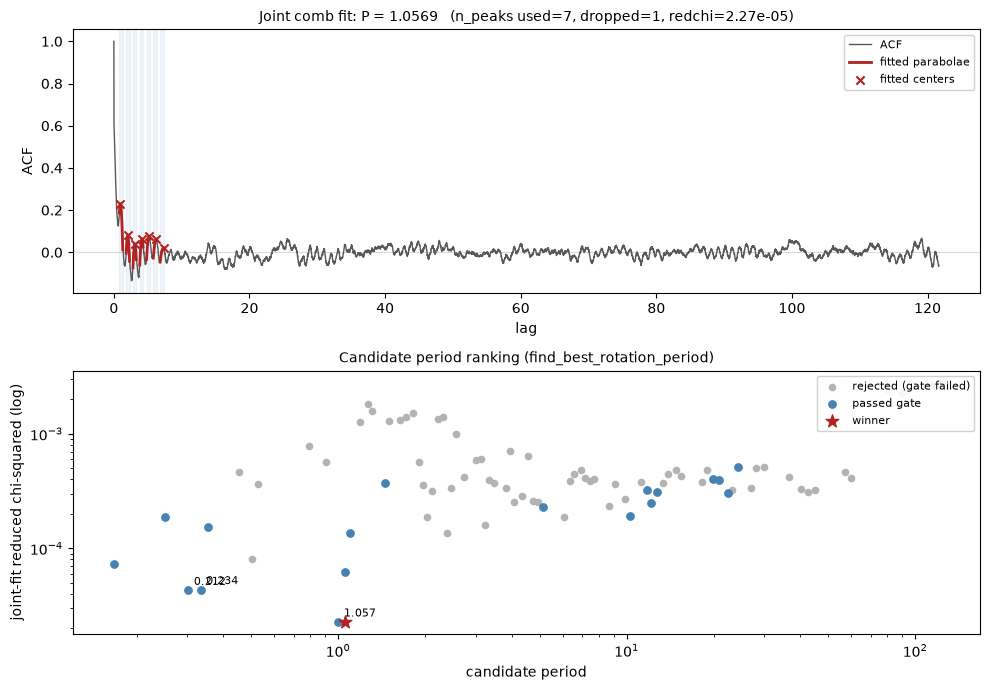

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
plot_comb_fit(acf_lags, acf, result.best_fit, ax=axes[0])
plot_candidate_ranking(result, ax=axes[1])
fig.tight_layout()
plt.show();

Initial guess (acf_fft): P0=22.7513  t0=0.0625
Fitted period: 22.2173 d  (true=0.9983000159263611)
Peaks used: 6  dropped: 2  reduced chi^2: 0.000213

Acceptance diagnostics:
  n_peaks_used: 6
  n_peaks_dropped: 2
  redchi: 0.00021299906725637073
  heights: [ 0.01603601 -0.00428784  0.00142779  0.00170156  0.01541933  0.00539869]
  height_snr: [ 0.62551207 -0.16725453  0.05569327  0.06637241  0.6014575   0.21058529]
  curvatures: [3.60317427e-04 9.94724123e-06 8.26290965e-12 1.98956752e-04
 6.89493145e-04 1.57433243e-16]
  frac_non_increasing_height: 0.4
  passes_min_peaks: True
  passes_redchi: True
  passes_height_snr: False


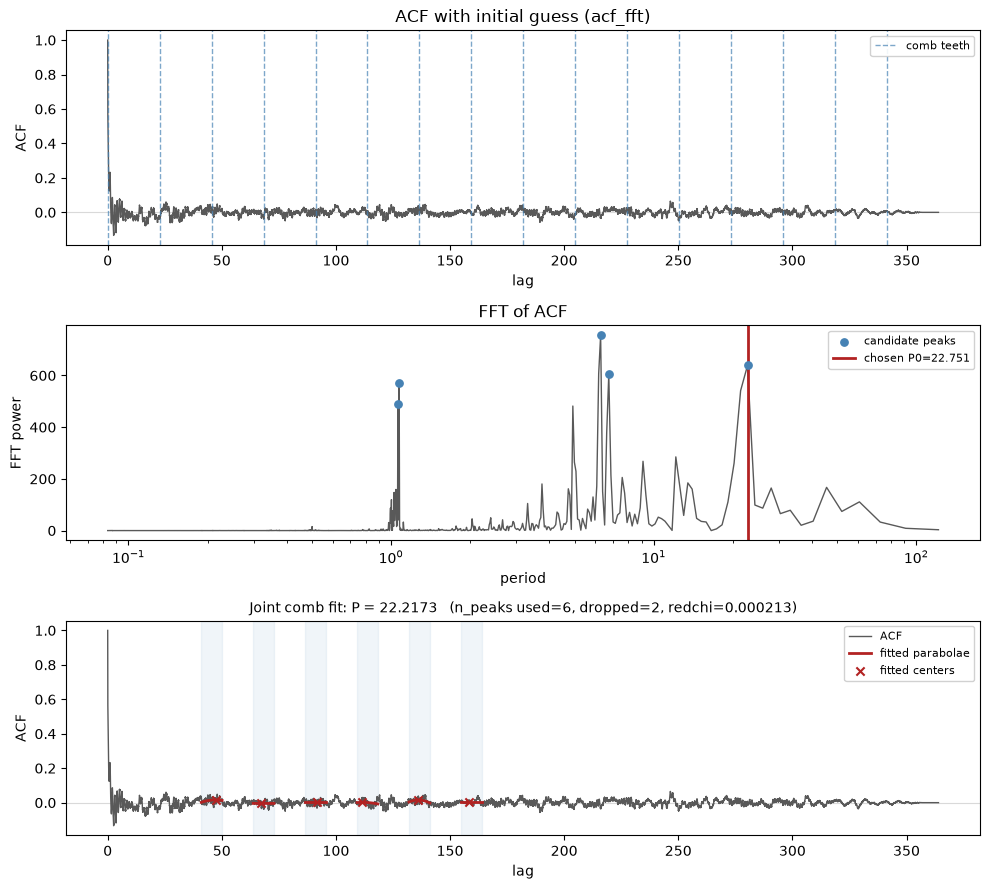


Saved diagnostic figure to comb_fit_diagnostic.png


In [ ]:
# with SMARTS data OLD
if __name__ == "__main__":
    # --- synthetic light curve: two spot harmonics + slow amplitude decay + noise ---
    flux, time = fe2, te2
    acf_lags, acf = lag_times2, acf_corr2
    true_P = expected_period

    # --- pick ONE initial-guess method (all three share the same call signature) ---
    # guess = guess_pairwise_histogram(time, flux, acf_lags, acf, prominence=0.01)
    # guess = guess_lombscargle(time, flux, acf_lags, acf)
    guess = guess_acf_fft(time, flux, acf_lags, acf)

    print(f"Initial guess ({guess.method}): P0={guess.P0:.4f}  t0={guess.t0:.4f}")

    # --- joint comb fit ---
    fit = fit_rotation_period(acf_lags, acf, guess, n_peaks=8, window_frac=0.2)
    print(f"Fitted period: {fit.P:.4f} d  (true={true_P})")
    print(f"Peaks used: {fit.n_peaks_used}  dropped: {fit.n_peaks_dropped}  "
          f"reduced chi^2: {fit.redchi:.4g}")

    # --- goodness-of-fit / acceptance diagnostics ---
    diagnostics = assess_rotation_candidate(fit, acf)
    print("\nAcceptance diagnostics:")
    for k, v in diagnostics.items():
        print(f"  {k}: {v}")

    # --- diagnostic plots ---
    fig, axes = plot_full_diagnostic(acf_lags, acf, guess, fit)
    plt.show();
    # fig.savefig("comb_fit_diagnostic.png", dpi=120)
    print("\nSaved diagnostic figure to comb_fit_diagnostic.png")

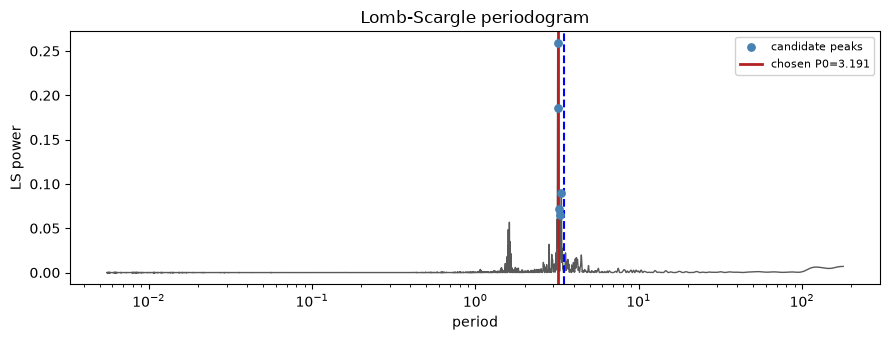

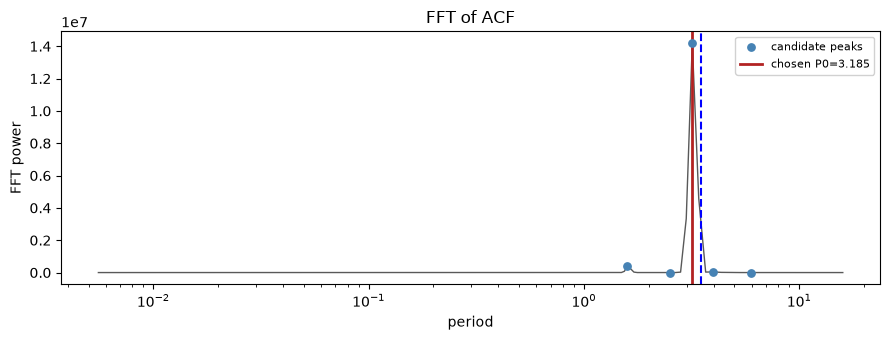

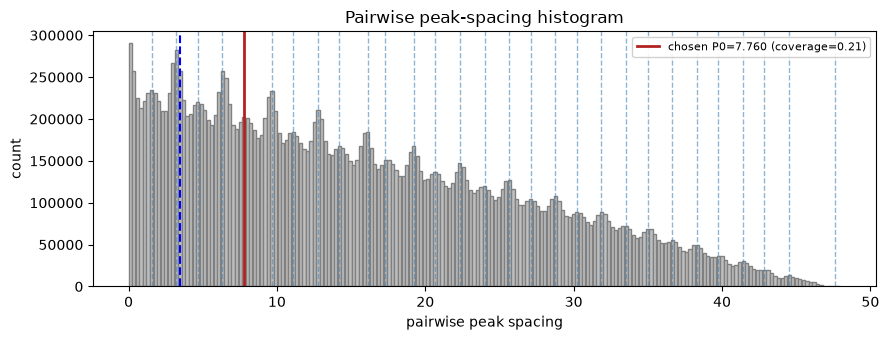

In [ ]:
from comb_fit import guess_lombscargle, guess_acf_fft
from plotting import plot_lombscargle_periodogram, plot_acf_fft_spectrum, plot_pairwise_spacing_histogram

# --- Lomb-Scargle periodogram ---
guess_ls = guess_lombscargle(time, flux, acf_lags, acf)
fig, ax = plot_lombscargle_periodogram(guess_ls)
ax.axvline(true_P, color='b', ls='--', label='true period')
# fig.savefig("ls_periodogram.png", dpi=120)
plt.show()

# --- FFT of the ACF ---
guess_fft = guess_acf_fft(time, flux, acf_lags, acf)
fig, ax = plot_acf_fft_spectrum(guess_fft)
ax.axvline(true_P, color='b', ls='--', label='true period')
# fig.savefig("acf_fft_spectrum.png", dpi=120)
plt.show()

# --- FFT of the ACF ---
guess_hist = guess_pairwise_histogram(time, flux, acf_lags, acf)
fig, ax = plot_pairwise_spacing_histogram(guess_hist)
ax.axvline(true_P, color='b', ls='--', label='true period')
# fig.savefig("acf_fft_spectrum.png", dpi=120)
plt.show()

In [ ]:
# save for export
# np.savez('tess_lc.npz', time=te1, flux=fe1)
# np.savez('smarts_lc_bad.npz', time=te2, flux=fe2)


## More SMARTS data testing

11.00279998779297
Filename: data/tess/012/smarts-tess-v1.0-060844.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   ()      
  1  LIGHTCURVE    1 BinTableHDU     15   17520R x 2C   [E, E]   
  2  WAVELET       1 ImageHDU        10   (64, 64)   uint8   
Expected period from SMARTS header: 11.00279998779297


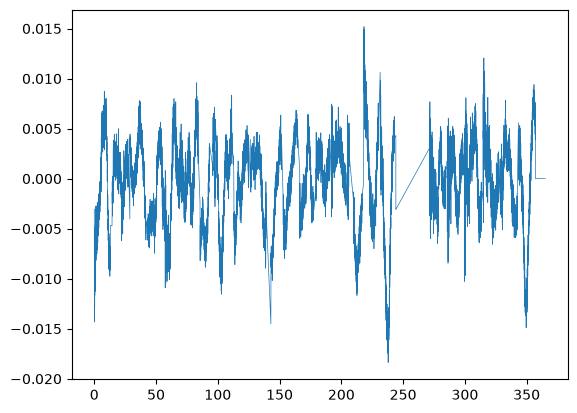

In [41]:
# open a SMARTS light curve to use as a test case
# fits_path = "data/tess/001/smarts-tess-v1.0-005025.fits"
# fits_path = "data/tess/012/smarts-tess-v1.0-060842.fits"
fits_path = "data/tess/012/smarts-tess-v1.0-060844.fits"
hdul = fits.open(fits_path)
print(hdul[0].header['PERIOD'])
hdul.info()

# extract the light curve data from the FITS file
lc2 = hdul["LIGHTCURVE"].data
time2 = lc2["time"]
flux2 = lc2["flux"] - 1
flux_err2 = ...   # some light curves may have errors, others may not
expected_period = hdul[0].header['PERIOD']
cadence = hdul[0].header['XPOSURE']

print('Expected period from SMARTS header:', expected_period)

# evenize
te2, fe2 = to_even_cadence(time2, flux2, timestep=1800)

plt.plot(te2, fe2, lw=0.5)
plt.show()

# # SMARTS
# nlags2 = ss.days_to_bins(np.floor(te2[-1] - te2[0]), 1800)
# acf_corr2 = acf(fe2, missing='conservative', nlags=nlags2, fft=True)
# lag_times2 = ss.bins_to_days(np.arange(len(acf_corr2)), 1800)

ACF computed: 5840 lag points, max lag = 121.65 d

Tested 107 candidate periods across 3 guess methods (failed: none)
Best period: P = 0.2007 d
  n_peaks_used=7  redchi=2.349e-06

Top 5 candidates (period, fitted P, n_peaks_used, redchi):
    0.2867 ->   0.2007  n_used=7  redchi=2.349e-06
    0.4300 ->   0.3010  n_used=7  redchi=3.191e-06
    5.6151 ->   7.0918  n_used=5  redchi=2.251e-05
    2.1345 ->   1.4942  n_used=6  redchi=5.271e-05
    4.8406 ->   6.2927  n_used=5  redchi=5.639e-05

Acceptance diagnostics for the winner:
  n_peaks_used: 7
  n_peaks_dropped: 1
  redchi: 2.3485158530549024e-06
  heights: [0.90250575 0.85364565 0.80575181 0.74655309 0.69519893 0.59666363
 0.51414107]
  height_snr: [5.89145444 5.57250128 5.25985575 4.87341326 4.53817918 3.894952
 3.35625415]
  curvatures: [1.22500297 0.4021934  0.49880524 0.43538685 0.43097763 0.29822334
 0.23748375]
  frac_non_increasing_height: 1.0
  passes_min_peaks: True
  passes_redchi: True
  passes_height_snr: True


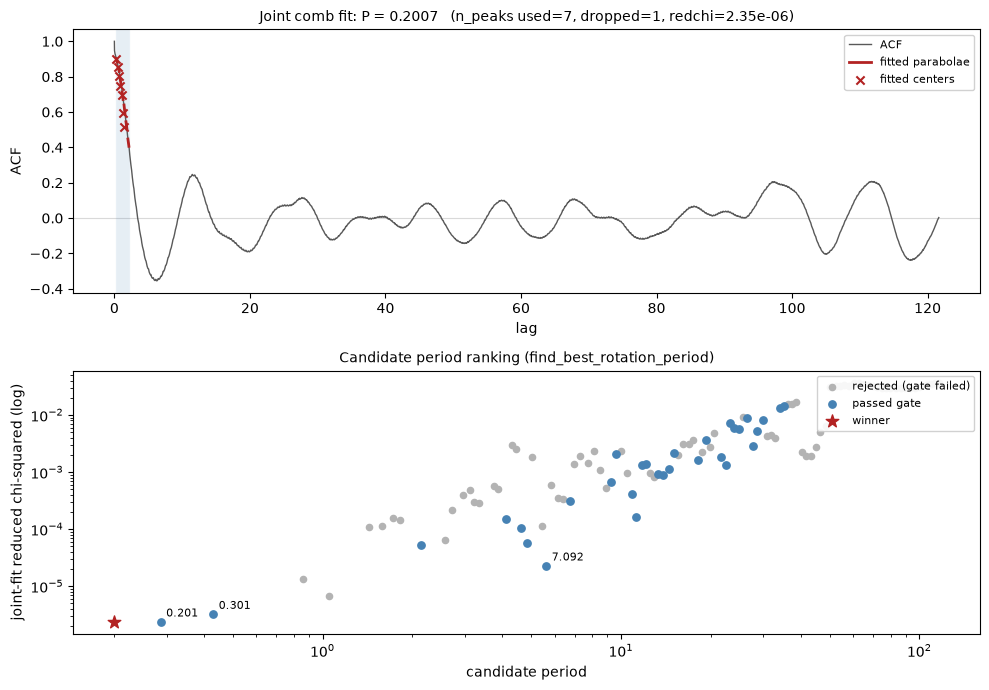

In [42]:
# with SMARTS data
if __name__ == "__main__":
    flux, time = fe2, te2
    # acf_lags, acf = lag_times2, acf_corr2
    true_P = expected_period
    
    # --- 1. gap-aware ACF ---
    acf_lags, acf = compute_acf(time, flux, max_lag_frac=1 / 3, min_valid_frac=0.3)
    print(f"ACF computed: {len(acf_lags)} lag points, max lag = {acf_lags[-1]:.2f} d")

    # --- 2. ensemble initial guess + joint-fit arbitration ---
    # If you have ANY prior expectation of the period range (spectral type,
    # literature, visual inspection of the light curve), pass min_period /
    # max_period here -- it meaningfully speeds things up and keeps
    # physically-impossible candidates out of contention. Left blank here
    # to demonstrate the fully-blind case.
    result = find_best_rotation_period(
        time, flux, acf_lags, acf,
        n_top_peaks=5,       # how many of each method's own top candidates to pool
        min_teeth=4,          # guard against few-tooth candidates winning trivially
        min_peaks_required=4, # winning candidate must retain at least this many peaks
    )

    print(f"\nTested {result.n_candidates_tried} candidate periods across "
          f"{3 - len(result.failed_methods)} guess methods "
          f"(failed: {result.failed_methods or 'none'})")
    print(f"Best period: P = {result.best_fit.P:.4f} d")
    print(f"  n_peaks_used={result.best_fit.n_peaks_used}  "
          f"redchi={result.best_fit.redchi:.4g}")

    print("\nTop 5 candidates (period, fitted P, n_peaks_used, redchi):")
    for c in result.candidates[:5]:
        print(f"  {c.period:8.4f} -> {c.fit.P:8.4f}  "
              f"n_used={c.fit.n_peaks_used}  redchi={c.fit.redchi:.4g}")

    diagnostics = assess_rotation_candidate(result.best_fit, acf)
    print("\nAcceptance diagnostics for the winner:")
    for k, v in diagnostics.items():
        print(f"  {k}: {v}")

# --- 3. diagnostic plots ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
plot_comb_fit(acf_lags, acf, result.best_fit, ax=axes[0])
plot_candidate_ranking(result, ax=axes[1])
fig.tight_layout()
# fig.savefig("messy_data_diagnostic.png", dpi=120)
plt.show();
# print("\nSaved diagnostic figure to messy_data_diagnostic.png")

In [51]:

guess.info
guess.P0

np.float64(30.416666666664938)

Initial guess (acf_fft): P0=30.4167  t0=0.0625
Fitted period: 14.2880 d  (true=11.00279998779297)
Peaks used: 8  dropped: 0  reduced chi^2: 0.0002652

Acceptance diagnostics:
  n_peaks_used: 8
  n_peaks_dropped: 0
  redchi: 0.0002652361925958161
  heights: [ 1.13733652  0.23414873  0.11083331  0.01751806  0.23634328  0.39232664
  0.48988736 -0.09393719]
  height_snr: [ 7.42440286  1.52849613  0.7235072   0.11435588  1.54282193  2.5610635
  3.1979287  -0.61321122]
  curvatures: [4.14268864e-02 4.46832590e-02 6.62953634e-03 1.39884703e-03
 1.70079671e-03 2.01987449e-03 1.59591841e-03 4.31789993e-56]
  frac_non_increasing_height: 0.5714285714285714
  passes_min_peaks: True
  passes_redchi: True
  passes_height_snr: False


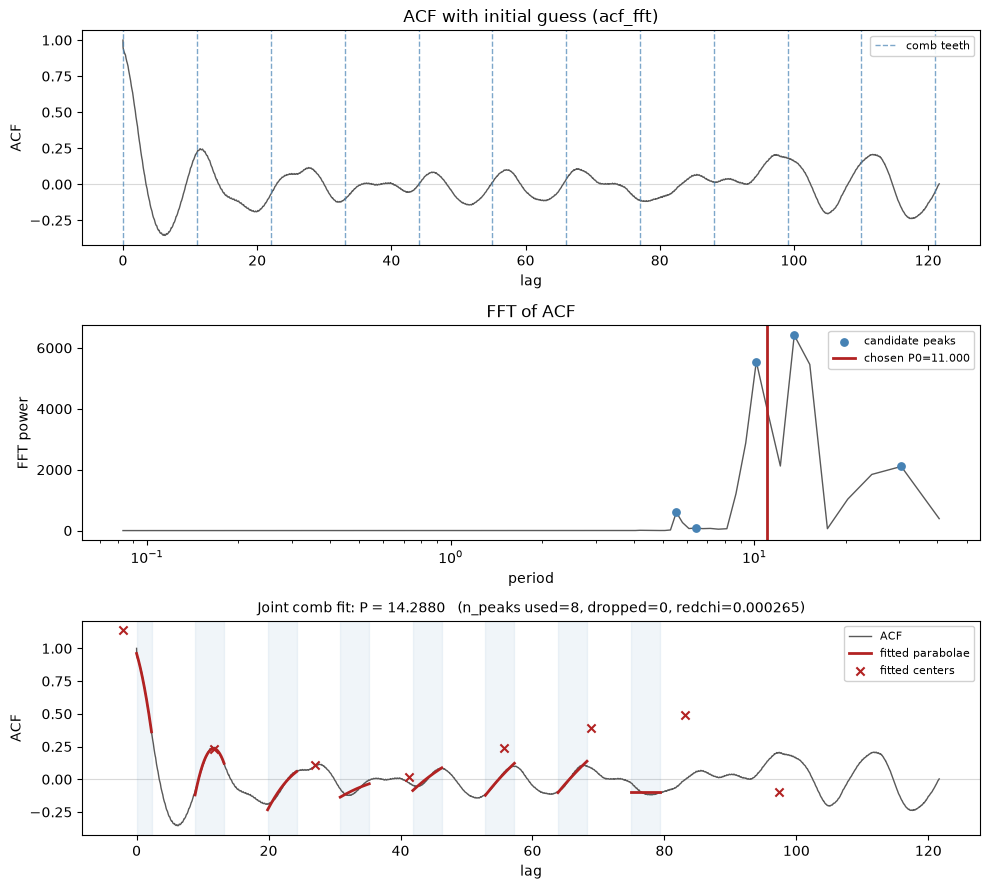


Saved diagnostic figure to comb_fit_diagnostic.png


In [ ]:
# with SMARTS data OLD
if __name__ == "__main__":
    # --- synthetic light curve: two spot harmonics + slow amplitude decay + noise ---
    flux, time = fe2, te2
    acf_lags, acf = compute_acf(time, flux, max_lag_frac=1 / 3, min_valid_frac=0.3)
    true_P = expected_period

    # --- pick ONE initial-guess method (all three share the same call signature) ---
    # guess = guess_pairwise_histogram(time, flux, acf_lags, acf, prominence=0.01)
    # guess = guess_lombscargle(time, flux, acf_lags, acf)
    guess = guess_acf_fft(time, flux, acf_lags, acf)

    print(f"Initial guess ({guess.method}): P0={guess.P0:.4f}  t0={guess.t0:.4f}")
    
    # # force an answer
    # guess.P0 = 11.0

    # --- joint comb fit ---
    fit = fit_rotation_period(acf_lags, acf, guess, n_peaks=8, window_frac=0.2)
    print(f"Fitted period: {fit.P:.4f} d  (true={true_P})")
    print(f"Peaks used: {fit.n_peaks_used}  dropped: {fit.n_peaks_dropped}  "
          f"reduced chi^2: {fit.redchi:.4g}")

    # --- goodness-of-fit / acceptance diagnostics ---
    diagnostics = assess_rotation_candidate(fit, acf)
    print("\nAcceptance diagnostics:")
    for k, v in diagnostics.items():
        print(f"  {k}: {v}")

    # --- diagnostic plots ---
    fig, axes = plot_full_diagnostic(acf_lags, acf, guess, fit)
    plt.show();
    # fig.savefig("comb_fit_diagnostic.png", dpi=120)
    print("\nSaved diagnostic figure to comb_fit_diagnostic.png")

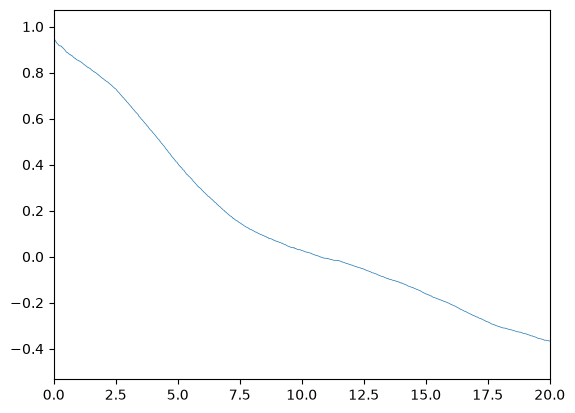

In [38]:
plt.plot(acf_lags, acf, lw=0.5)
plt.xlim([0, 20])
plt.show()